# The Digital Transformation of Banking
### How U.S. Households Changed the Way They Acces Bank Accounts, 2019-2023

## Motivation
Technology has changed the way people do many everyday activities, including banking. Today, many customers can check their accounts, transfer money, and manage their finances without going to a bank branch.

I chose this topic for my background in Banking and Finace, and my interest in technology. I wanted to see how the way people acces their bank accounts has changed in recent years and if income make a difference in the use of mobile banking.

## Research Question
How did the way U.S. households access their bank accounts change from 2019 to 2023, and how does mobile banking use differ by age and income?

## Data Source

Source: FDIC National Survey of Unbanked and Underbanked Households.

The dataset contains the most common methods U.S. banked households use to acces their bank accounts. This analysis uses data from 2019, 2021, and 2023

The dataset includes banking access methods such as:

-Bank teller

-ATM or bank kiosk

-Telephone banking

-Online banking

-Mobile banking

It also includes household characteristics such as age and family income.



## Data Cleaning and Preparation

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd

In [31]:
ruta_exacta = '/content/drive/MyDrive/Most_common_way_to_access_account_for_Nation_MultiYear_by_Selected_Household_Characteristics.csv'

In [32]:
df = pd.read_csv(ruta_exacta, skiprows=2)
df.head()

,Unnamed: 0,2023,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,2021,...,Unnamed: 15,Unnamed: 16,2019,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,Row Variables,Number of Households (1000s),Number of Households (PCT),Bank teller,ATM or bank kiosk,Telephone banking,Online banking,Mobile banking,Other,Number of Households (1000s),...,Mobile banking,Other,Number of Households (1000s),Number of Households (PCT),Bank teller,ATM or bank kiosk,Telephone banking,Online banking,Mobile banking,Other
1,All Households,126222,100,15.1,13.8,2.3,19.8,48.3,0.7,124385,...,43.5,0.7,120847,100,21.0,19.5,2.4,22.8,34.0,0.3
2,Race/Ethnicity (PCT),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Black,15014,100,16.5,19.2,2.9,12.2,48.5,0.7,14676,...,45.4,0.7,13836,100,20.6,27.0,3.1,12.0,37.2,0.2
4,Hispanic,17595,100,14.6,17.7,1.5,11.0,54.7,0.5,17187,...,49.6,0.5,15504,100,20.9,24.3,2.1,11.1,41.3,0.2


In [33]:
df.columns

Index(['Unnamed: 0', '2023', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', '2021',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', '2019', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24'],
      dtype='object')

In [34]:
df.iloc[0]

,0
Unnamed: 0,Row Variables
2023,Number of Households (1000s)
Unnamed: 2,Number of Households (PCT)
Unnamed: 3,Bank teller
Unnamed: 4,ATM or bank kiosk
Unnamed: 5,Telephone banking
Unnamed: 6,Online banking
Unnamed: 7,Mobile banking
Unnamed: 8,Other
2021,Number of Households (1000s)


In [35]:
df.columns = [
    'category',

    'households_2023',
    'households_pct_2023',
    'bank_teller_2023',
    'atm_2023',
    'telephone_2023',
    'online_2023',
    'mobile_2023',
    'other_2023',

    'households_2021',
    'households_pct_2021',
    'bank_teller_2021',
    'atm_2021',
    'telephone_2021',
    'online_2021',
    'mobile_2021',
    'other_2021',

    'households_2019',
    'households_pct_2019',
    'bank_teller_2019',
    'atm_2019',
    'telephone_2019',
    'online_2019',
    'mobile_2019',
    'other_2019'
]

In [36]:
df = df.drop(index=0).reset_index(drop=True)
df.head()

,category,households_2023,households_pct_2023,bank_teller_2023,atm_2023,telephone_2023,online_2023,mobile_2023,other_2023,households_2021,...,mobile_2021,other_2021,households_2019,households_pct_2019,bank_teller_2019,atm_2019,telephone_2019,online_2019,mobile_2019,other_2019
0,All Households,126222,100,15.1,13.8,2.3,19.8,48.3,0.7,124385,...,43.5,0.7,120847,100,21.0,19.5,2.4,22.8,34.0,0.3
1,Race/Ethnicity (PCT),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Black,15014,100,16.5,19.2,2.9,12.2,48.5,0.7,14676,...,45.4,0.7,13836,100,20.6,27.0,3.1,12.0,37.2,0.2
3,Hispanic,17595,100,14.6,17.7,1.5,11.0,54.7,0.5,17187,...,49.6,0.5,15504,100,20.9,24.3,2.1,11.1,41.3,0.2
4,Asian,7102,100,11.1,9.9,1.3,22.5,54.3,0.9,6736,...,48.6,0.6,6756,100,18.4,15.2,1.3,25.7,39.3,-


In [37]:
df.shape

(43, 25)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             43 non-null     object
 1   households_2023      31 non-null     object
 2   households_pct_2023  31 non-null     object
 3   bank_teller_2023     31 non-null     object
 4   atm_2023             31 non-null     object
 5   telephone_2023       31 non-null     object
 6   online_2023          31 non-null     object
 7   mobile_2023          31 non-null     object
 8   other_2023           31 non-null     object
 9   households_2021      30 non-null     object
 10  households_pct_2021  31 non-null     object
 11  bank_teller_2021     30 non-null     object
 12  atm_2021             30 non-null     object
 13  telephone_2021       30 non-null     object
 14  online_2021          30 non-null     object
 15  mobile_2021          30 non-null     object
 16  other_2021

In [39]:
df['category'].tolist()

['All Households',
 'Race/Ethnicity (PCT) ',
 'Black',
 'Hispanic',
 'Asian',
 'American Indian or Alaska Native',
 'Native Hawaiian or Other Pacific Islander',
 'White',
 'Two or More Races',
 'Age group (PCT) ',
 '15 to 24 years',
 '25 to 34 years',
 '35 to 44 years',
 '45 to 54 years',
 '55 to 64 years',
 '65 years or more',
 'Education (PCT) ',
 'No high school diploma',
 'High school diploma',
 'Some college',
 'College degree',
 'Employment status (PCT) ',
 'Employed',
 'Unemployed',
 'Not in labor force',
 'Family income (PCT) ',
 'Less than $15,000',
 '$15,000 to $30,000',
 '$30,000 to $50,000',
 '$50,000 to $75,000',
 'At least $75,000',
 'Disability status (PCT) ',
 'Disabled, aged 25 to 64',
 'Not disabled, aged 25 to 64',
 'Metropolitan and nonmetropolitan status (PCT) ',
 'Metropolitan area',
 'Not in metropolitan area',
 'Not identified',
 'Source: Multiyear FDIC National Surveys of Unbanked and Underbanked Households.',
 '2017 estimates may not match previously published

In [40]:
numeric_columns = df.columns[1:]

In [41]:
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category             43 non-null     object 
 1   households_2023      31 non-null     float64
 2   households_pct_2023  31 non-null     float64
 3   bank_teller_2023     31 non-null     float64
 4   atm_2023             31 non-null     float64
 5   telephone_2023       31 non-null     float64
 6   online_2023          31 non-null     float64
 7   mobile_2023          31 non-null     float64
 8   other_2023           30 non-null     float64
 9   households_2021      30 non-null     float64
 10  households_pct_2021  31 non-null     float64
 11  bank_teller_2021     30 non-null     float64
 12  atm_2021             30 non-null     float64
 13  telephone_2021       30 non-null     float64
 14  online_2021          30 non-null     float64
 15  mobile_2021          30 non-null     float

## Data Analysis

## Banking Trends

I looked at all U.S. households to understand how the most common ways of accessing bank accounts changed between 2019 and 2023.

In [43]:
all_households = df[df['category'] == 'All Households']
all_households

,category,households_2023,households_pct_2023,bank_teller_2023,atm_2023,telephone_2023,online_2023,mobile_2023,other_2023,households_2021,...,mobile_2021,other_2021,households_2019,households_pct_2019,bank_teller_2019,atm_2019,telephone_2019,online_2019,mobile_2019,other_2019
0,All Households,126222.0,100.0,15.1,13.8,2.3,19.8,48.3,0.7,124385.0,...,43.5,0.7,120847.0,100.0,21.0,19.5,2.4,22.8,34.0,0.3


In [44]:
banking_chanels = all_households[['bank_teller_2019', 'atm_2019', 'online_2019', 'mobile_2019', 'bank_teller_2021', 'atm_2021', 'online_2021', 'mobile_2021', 'bank_teller_2023', 'atm_2023', 'online_2023', 'mobile_2023']]
banking_chanels

,bank_teller_2019,atm_2019,online_2019,mobile_2019,bank_teller_2021,atm_2021,online_2021,mobile_2021,bank_teller_2023,atm_2023,online_2023,mobile_2023
0,21.0,19.5,22.8,34.0,14.9,16.0,22.0,43.5,15.1,13.8,19.8,48.3


In [45]:
mobile_change = all_households['mobile_2023'].iloc[0] - all_households['mobile_2019'].iloc[0]
online_change = all_households['online_2023'].iloc[0] - all_households['online_2019'].iloc[0]
teller_change = all_households['bank_teller_2023'].iloc[0] - all_households['bank_teller_2019'].iloc[0]
atm_change = all_households['atm_2023'].iloc[0] - all_households['atm_2019'].iloc[0]


In [46]:
print("Mobile banking:", round(mobile_change,1))
print("Online banking:", round(online_change,1))
print("Bank tellers:", round(teller_change,1))
print("ATMs:", round(atm_change,1))

Mobile banking: 14.3
Online banking: -3.0
Bank tellers: -5.9
ATMs: -5.7


In [47]:
years = [2019, 2021, 2023]
mobile = [all_households['mobile_2019'].iloc[0], all_households['mobile_2021'].iloc[0], all_households['mobile_2023'].iloc[0]]
online = [all_households['online_2019'].iloc[0], all_households['online_2021'].iloc[0], all_households['online_2023'].iloc[0]]
teller = [all_households['bank_teller_2019'].iloc[0], all_households['bank_teller_2021'].iloc[0], all_households['bank_teller_2023'].iloc[0]]
atm = [all_households['atm_2019'].iloc[0], all_households['atm_2021'].iloc[0], all_households['atm_2023'].iloc[0]]


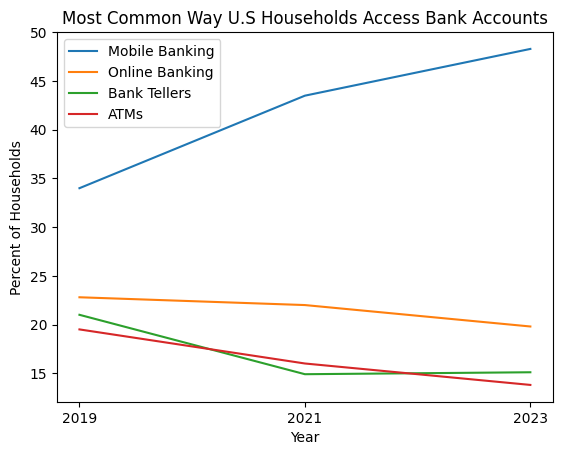

In [48]:
import matplotlib.pyplot as plt
plt.plot(years, mobile, label='Mobile Banking')
plt.plot(years, online, label='Online Banking')
plt.plot(years, teller, label='Bank Tellers')
plt.plot(years, atm, label='ATMs')
plt.title('Most Common Way U.S Households Access Bank Accounts')
plt.xlabel('Year')
plt.ylabel('Percent of Households')
plt.xticks(years)
plt.legend()
plt.show()

## Mobile Banking by Age Group

Then, I compared mobile banking across different age groups to see how the use of mobile banking changes with age.

In [49]:
age_groups = df[df['category'].isin(['15 to 24 years', '25 to 34 years', '35 to 44 years', '45 to 54 years', '55 to 64 years', '65 years or more'])]
age_groups

,category,households_2023,households_pct_2023,bank_teller_2023,atm_2023,telephone_2023,online_2023,mobile_2023,other_2023,households_2021,...,mobile_2021,other_2021,households_2019,households_pct_2019,bank_teller_2019,atm_2019,telephone_2019,online_2019,mobile_2019,other_2019
10,15 to 24 years,5822.0,100.0,5.5,9.9,1.1,6.7,76.6,0.3,5468.0,...,74.1,NaN,5643.0,100.0,10.2,17.3,2.2,7.2,62.9,0.1
11,25 to 34 years,19913.0,100.0,4.6,9.8,0.7,9.8,74.8,0.3,20299.0,...,69.4,0.3,19714.0,100.0,8.0,15.1,0.6,14.4,61.7,0.2
12,35 to 44 years,22035.0,100.0,6.4,12.0,0.8,14.0,66.4,0.3,21383.0,...,60.5,0.2,20699.0,100.0,10.6,18.2,1.1,20.1,49.8,0.2
13,45 to 54 years,20556.0,100.0,10.3,13.2,1.2,20.1,54.7,0.5,20878.0,...,49.1,0.3,20900.0,100.0,15.5,19.9,1.6,26.6,36.3,0.1
14,55 to 64 years,22614.0,100.0,15.8,16.0,2.3,25.8,39.7,0.5,23053.0,...,33.2,0.6,22599.0,100.0,24.3,21.9,2.9,29.3,21.3,0.3
15,65 years or more,35282.0,100.0,30.4,16.7,5.1,27.2,19.3,1.4,33304.0,...,15.3,1.5,31292.0,100.0,39.2,21.6,4.5,25.7,8.3,0.7


In [50]:
age_2023 = age_groups[['category', 'bank_teller_2023', 'atm_2023', 'online_2023', 'mobile_2023']]
age_2023

,category,bank_teller_2023,atm_2023,online_2023,mobile_2023
10,15 to 24 years,5.5,9.9,6.7,76.6
11,25 to 34 years,4.6,9.8,9.8,74.8
12,35 to 44 years,6.4,12.0,14.0,66.4
13,45 to 54 years,10.3,13.2,20.1,54.7
14,55 to 64 years,15.8,16.0,25.8,39.7
15,65 years or more,30.4,16.7,27.2,19.3


In [51]:
age_years = age_groups[['category', 'mobile_2019', 'mobile_2021', 'mobile_2023']]
age_years

,category,mobile_2019,mobile_2021,mobile_2023
10,15 to 24 years,62.9,74.1,76.6
11,25 to 34 years,61.7,69.4,74.8
12,35 to 44 years,49.8,60.5,66.4
13,45 to 54 years,36.3,49.1,54.7
14,55 to 64 years,21.3,33.2,39.7
15,65 years or more,8.3,15.3,19.3


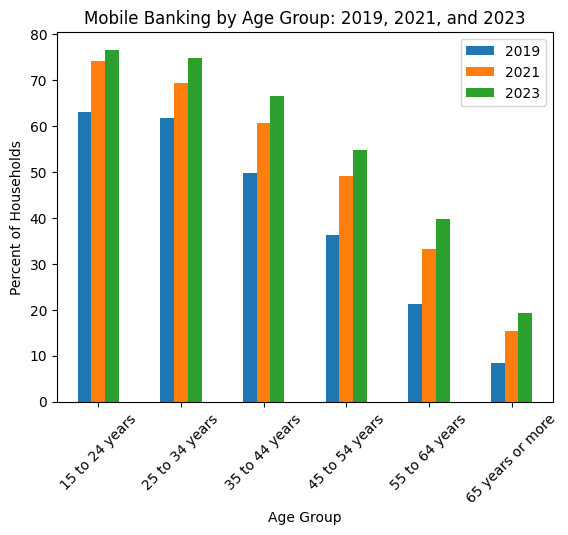

In [52]:
age_years.plot(
    x='category',
    y=['mobile_2019', 'mobile_2021', 'mobile_2023'],
    kind='bar')

plt.xlabel('Age Group')
plt.ylabel('Percent of Households')
plt.title('Mobile Banking by Age Group: 2019, 2021, and 2023')
plt.xticks(rotation=45)
plt.legend(['2019', '2021', '2023'])
plt.show()

In [54]:
age_years = age_years.copy()
age_years['mobile_change'] = age_years['mobile_2023'] - age_years['mobile_2019']

In [55]:
age_years[['category', 'mobile_2019', 'mobile_2023', 'mobile_change']]

,category,mobile_2019,mobile_2023,mobile_change
10,15 to 24 years,62.9,76.6,13.7
11,25 to 34 years,61.7,74.8,13.1
12,35 to 44 years,49.8,66.4,16.6
13,45 to 54 years,36.3,54.7,18.4
14,55 to 64 years,21.3,39.7,18.4
15,65 years or more,8.3,19.3,11.0


## Mobile Banking by Income Group

After looking at age groups, I analyzed if income also shows differences in mobile banking. I compared different income groups and looked at how mobile banking from 2019 to 2023.

In [25]:
income_groups = df[df['category'].isin(['Less than $15,000', '$15,000 to $30,000', '$30,000 to $50,000', '$50,000 to $75,000', 'At least $75,000'])].copy()
income_groups

,category,households_2023,households_pct_2023,bank_teller_2023,atm_2023,telephone_2023,online_2023,mobile_2023,other_2023,households_2021,...,mobile_2021,other_2021,households_2019,households_pct_2019,bank_teller_2019,atm_2019,telephone_2019,online_2019,mobile_2019,other_2019
26,"Less than $15,000",8065.0,100.0,27.4,20.6,5.2,10.2,35.1,1.5,9498.0,...,33.9,1.8,9761.0,100.0,35.9,23.6,5.8,9.9,23.5,1.3
27,"$15,000 to $30,000",13426.0,100.0,27.8,19.9,5.6,13.5,31.9,1.3,15659.0,...,33.4,1.3,16027.0,100.0,31.7,24.7,4.7,12.7,25.9,0.4
28,"$30,000 to $50,000",21334.0,100.0,21.4,16.7,3.3,14.9,42.8,0.9,23074.0,...,39.4,0.5,22822.0,100.0,24.7,21.7,2.8,17.1,33.2,0.5
29,"$50,000 to $75,000",23230.0,100.0,15.7,14.5,2.1,18.3,48.8,0.6,23837.0,...,44.9,0.6,23065.0,100.0,20.3,20.4,2.1,21.2,35.9,0.2
30,"At least $75,000",60168.0,100.0,8.2,10.2,0.9,24.8,55.6,0.3,52317.0,...,49.3,0.4,49172.0,100.0,13.1,15.6,0.9,32.1,38.1,0.2


In [ ]:
income_2023 = income_groups[['category', 'mobile_2023']]
income_2023

,category,mobile_2023
26,"Less than $15,000",35.1
27,"$15,000 to $30,000",31.9
28,"$30,000 to $50,000",42.8
29,"$50,000 to $75,000",48.8
30,"At least $75,000",55.6


In [26]:
income_years = income_groups[['category', 'mobile_2019', 'mobile_2021', 'mobile_2023']]
income_years

,category,mobile_2019,mobile_2021,mobile_2023
26,"Less than $15,000",23.5,33.9,35.1
27,"$15,000 to $30,000",25.9,33.4,31.9
28,"$30,000 to $50,000",33.2,39.4,42.8
29,"$50,000 to $75,000",35.9,44.9,48.8
30,"At least $75,000",38.1,49.3,55.6


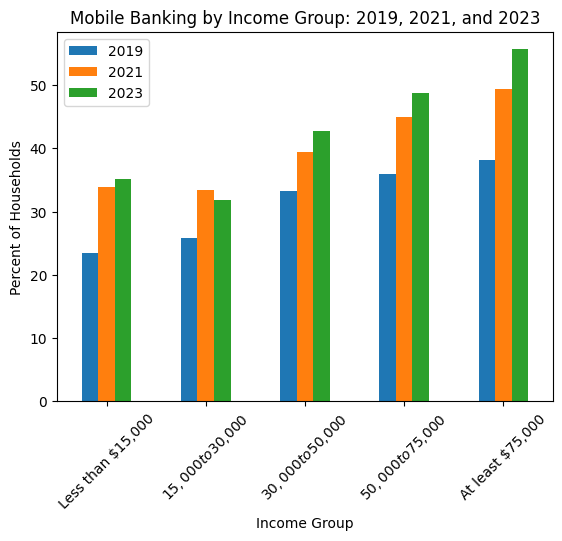

In [27]:
income_years.plot(
    x='category',
    y=['mobile_2019', 'mobile_2021', 'mobile_2023'],
    kind='bar')

plt.xlabel('Income Group')
plt.ylabel('Percent of Households')
plt.title('Mobile Banking by Income Group: 2019, 2021, and 2023')
plt.xticks(rotation=45)
plt.legend(['2019', '2021', '2023'])
plt.show()

In [56]:
income_groups['mobile_change'] = (income_groups['mobile_2023'] - income_groups['mobile_2019'])
income_groups[['category', 'mobile_2019', 'mobile_2023', 'mobile_change']]


,category,mobile_2019,mobile_2023,mobile_change
26,"Less than $15,000",23.5,35.1,11.6
27,"$15,000 to $30,000",25.9,31.9,6.0
28,"$30,000 to $50,000",33.2,42.8,9.6
29,"$50,000 to $75,000",35.9,48.8,12.9
30,"At least $75,000",38.1,55.6,17.5


In [57]:
income_groups['online_change'] = income_groups['online_2023'] - income_groups['online_2019']
income_groups[['category', 'online_2019', 'online_2023', 'online_change']]


,category,online_2019,online_2023,online_change
26,"Less than $15,000",9.9,10.2,0.3
27,"$15,000 to $30,000",12.7,13.5,0.8
28,"$30,000 to $50,000",17.1,14.9,-2.2
29,"$50,000 to $75,000",21.2,18.3,-2.9
30,"At least $75,000",32.1,24.8,-7.3


## Descriptive Statistics

To summarize the data, I calculated the mean, median, minimun, and maximun for mobile banking across age and income groups in 2023.

In [58]:
print("Mean:", age_groups['mobile_2023'].mean())
print("Median:", age_groups['mobile_2023'].median())
print("Minimum:", age_groups['mobile_2023'].min())
print("Maximum:", age_groups['mobile_2023'].max())

Mean: 55.25
Median: 60.550000000000004
Minimum: 19.3
Maximum: 76.6


In [59]:
print("Mean:", income_groups['mobile_2023'].mean())
print("Median:", income_groups['mobile_2023'].median())
print("Minimum:", income_groups['mobile_2023'].min())
print("Maximum:", income_groups['mobile_2023'].max())

Mean: 42.839999999999996
Median: 42.8
Minimum: 31.9
Maximum: 55.6


## Key Findings
-Mobile banking increased from 34.0% in 2019 to 48.3% in 2023 among U.S. banked households.

-Traditional banking methods decreased during the same period. Bank teller use decreased from 21.0% to 15.1%, while ATM use decreased from 19.5% to 13.8%.

-In 2023, mobile banking use was highest among younger age groups. It was 76.6% for ages 15-24 compared with 19.3% for ages 65 or older.

## Conclusion

The analysis shows a clear change in how U.S. households access their bank accounts. Between 2019 and 2023, mobile banking became more common, while  traditional methods such as bank tellers and ATMs became less common.

Age and income were also associated with differences in mobile banking use. Younger households showed higher mobile banking use in 2023, while older households showed lower use. Higher-income households also generally showed higher mobile banking use.

Overall, the results show a shift toward mobile banking as the main way households access their bank accounts, although the shift differs across age and income groups.